In [1]:
# A/B Test: Delivery Time
# Цель: проверить, снижает ли новая фича время доставки
# Описание данных:	
# order_id - id заказа
# delivery_time - время доставки в минутах
# district - район доставки
# experiment_group - экспериментальная группа


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import ks_2samp

In [3]:
df = pd.read_csv(r'..\data\4 experiment_lesson_4.csv')

In [4]:
## Первичный анализ

In [5]:
df_groupA = df.loc[df['experiment_group'] == 'control']
df_groupB = df.loc[df['experiment_group'] == 'test']
print(df_groupA['delivery_time'].mean())
print(df_groupB['delivery_time'].mean())

45.065101070154576
39.04681314330958


In [6]:
mean_diff = df_groupA['delivery_time'].mean() - df_groupB['delivery_time'].mean()

In [7]:
len(df_groupA) - len(df_groupB)

-12

In [8]:
## Статистический тест

In [9]:
se = np.sqrt(df_groupA['delivery_time'].var() / len(df_groupA) + df_groupB['delivery_time'].var() / len(df_groupB))
print(round(se, 2))

0.14


In [10]:
# делаем t-test

In [11]:
stats.ttest_ind(df_groupA['delivery_time'], df_groupB['delivery_time'], equal_var=False)

TtestResult(statistic=np.float64(43.03555202424146), pvalue=np.float64(0.0), df=np.float64(20191.127787584748))

In [12]:
## Проверка данных: выбросы, форма распределения

<Axes: >

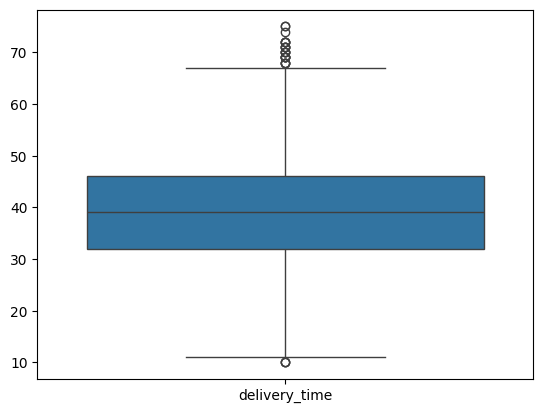

In [13]:
sns.boxplot(data=[df_groupA['delivery_time'], df_groupB['delivery_time']])

<Axes: xlabel='delivery_time', ylabel='Count'>

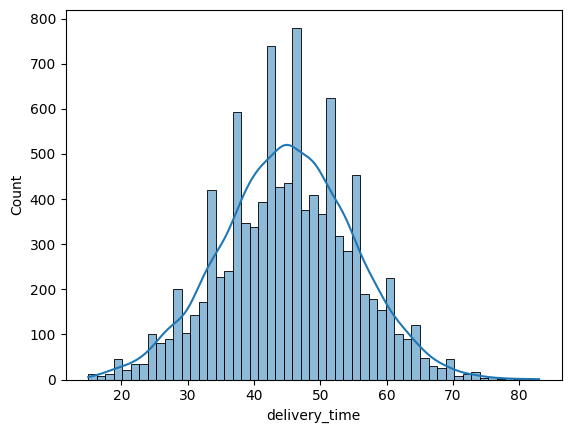

In [14]:
sns.histplot(df_groupA['delivery_time'], kde=True)

<Axes: xlabel='delivery_time', ylabel='Count'>

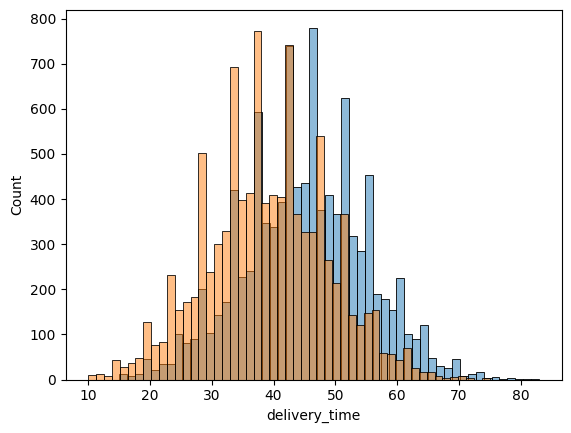

In [15]:
sns.histplot(df_groupA['delivery_time'], alpha = 0.5)
sns.histplot(df_groupB['delivery_time'], alpha = 0.5)

In [16]:
## Проверка по сегментам

In [17]:
ks_2samp(df_groupA['delivery_time'], df_groupB['delivery_time'])

KstestResult(statistic=np.float64(0.2419652498674899), pvalue=np.float64(1.0789827056931934e-260), statistic_location=np.float64(43.0), statistic_sign=np.int8(-1))

In [18]:
df.groupby(['district', 'experiment_group']).size()

district  experiment_group
Central   control              669
          test                1727
Purlieus  control             8781
          test                8179
Suburb    control              642
          test                 198
dtype: int64

In [19]:
# Считаем среднее время доставки по районам и группам

In [20]:
df.groupby(['district', 'experiment_group'])['delivery_time'].mean()

district  experiment_group
Central   control             26.239163
          test                24.608570
Purlieus  control             45.125384
          test                41.603986
Suburb    control             63.858255
          test                59.348485
Name: delivery_time, dtype: float64

In [21]:
### Новая фича стабильно снижает время доставки во всех районах (на ~2–4 минуты).
### Однако общий эффект (~6 минут) частично завышен из-за дисбаланса распределения заказов по районам между группами.
### С учётом этого, фичу можно рекомендовать к внедрению, но ожидаемый эффект следует оценивать ближе к 2–4 минутам.